
# PCA-Dimensionsreduktion


Nur mit numerischen Daten durchführen (keine One-Hot-Encoded)


In [1]:
import pandas as pd
import numpy as np

from sklearn import svm
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("One-Hot-Encoded.csv")

df = df.select_dtypes(include=["number"]).copy()




## Numerische Features auswählen



In [3]:
X = df.select_dtypes(include=[np.number])

print("Numerische Matrix vor dropna:", X.shape)

X = X.dropna(axis=0)

print("Numerische Matrix nach dropna:", X.shape)


Numerische Matrix vor dropna: (47514, 9)
Numerische Matrix nach dropna: (15651, 9)



## Pipeline und PCA



In [5]:
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X)

dim_reduction = PCA(n_components=0.9)

pipeline_2 = Pipeline([
    ("scaler", scaler),
    ("dim_reduction", dim_reduction)
])

X_pca = pipeline_2.fit(X_scaled)

X_pca

,steps,"[('scaler', ...), ('dim_reduction', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,0.9
,copy,True
,whiten,False
,svd_solver,'auto'


In [6]:
X_pca = pipeline_2.fit_transform(X)

print("PCA-Ergebnisform:", X_pca.shape)
print("Erklärte Varianz gesamt:",
      pipeline_2.named_steps["dim_reduction"].explained_variance_ratio_.sum())

X_pca      


PCA-Ergebnisform: (15651, 5)
Erklärte Varianz gesamt: 0.9563805275114072


array([[-1.05191046, -0.0125903 ,  1.89668862,  0.27612245,  0.20135473],
       [-1.56316277,  0.43550816,  1.11469326,  0.20761294, -0.11397972],
       [-0.84424944, -0.41991444,  0.26326485, -0.79194504,  1.02454534],
       ...,
       [ 1.04391493, -0.05921731,  1.23404148,  0.70556274, -0.26853261],
       [-1.6883837 , -0.13002767, -0.12420309,  0.62175249, -0.73503801],
       [-1.91247803, -0.3424045 , -0.05257774, -0.46391355,  0.64036366]],
      shape=(15651, 5))


## 2D-Plot




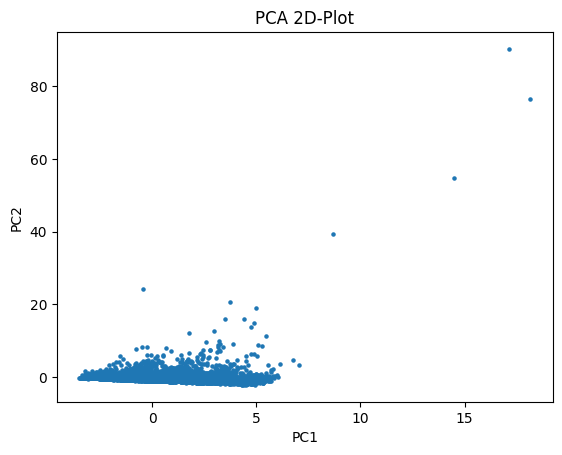

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D-Plot")
plt.show()
